In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv(r"C:\Users\Arshia Sood\Downloads\data-export (1).csv")

In [4]:
print(data.head(10))

          # ----------------------------------------  \
0  Session primary channel group (Default channel...   
1                                             Direct   
2                                     Organic Social   
3                                             Direct   
4                                     Organic Social   
5                                     Organic Social   
6                                     Organic Social   
7                                     Organic Social   
8                                             Direct   
9                                     Organic Social   

                 Unnamed: 1 Unnamed: 2 Unnamed: 3        Unnamed: 4  \
0  Date + hour (YYYYMMDDHH)      Users   Sessions  Engaged sessions   
1                2024041623        237        300               144   
2                2024041719        208        267               132   
3                2024041723        188        233               115   
4                2024041718 

In [5]:
print(data.shape)
print(data.columns)

(3183, 10)
Index(['# ----------------------------------------', 'Unnamed: 1',
       'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='object')


In [6]:
print(data.head(1))

          # ----------------------------------------  \
0  Session primary channel group (Default channel...   

                 Unnamed: 1 Unnamed: 2 Unnamed: 3        Unnamed: 4  \
0  Date + hour (YYYYMMDDHH)      Users   Sessions  Engaged sessions   

                            Unnamed: 5                 Unnamed: 6  \
0  Average engagement time per session  Engaged sessions per user   

           Unnamed: 7       Unnamed: 8   Unnamed: 9  
0  Events per session  Engagement rate  Event count  


In [7]:
data.columns=data.iloc[0]
data.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [8]:
data=data.drop(index=0).reset_index(drop=True)
data.columns=["Channel Group","Date Hour","Users","Sessions","Engaged Sessions","Average Engagement time per Session","Engaged sessions per user","Events per session","Engagement rate","Event count"]

In [10]:
print(data.head())

    Channel Group   Date Hour Users Sessions Engaged Sessions  \
0          Direct  2024041623   237      300              144   
1  Organic Social  2024041719   208      267              132   
2          Direct  2024041723   188      233              115   
3  Organic Social  2024041718   187      256              125   
4  Organic Social  2024041720   175      221              112   

  Average Engagement time per Session Engaged sessions per user  \
0                  47.526666666666700        0.6075949367088610   
1                   32.09737827715360        0.6346153846153850   
2                   39.93991416309010        0.6117021276595740   
3                         32.16015625        0.6684491978609630   
4                  46.918552036199100                      0.64   

  Events per session      Engagement rate Event count  
0  4.673333333333330                 0.48        1402  
1  4.295880149812730   0.4943820224719100        1147  
2  4.587982832618030  0.49356223175965

In [11]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Channel Group                        3182 non-null   object
 1   Date Hour                            3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged Sessions                     3182 non-null   object
 5   Average Engagement time per Session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB
None


In [14]:
data["Date Hour"]=pd.to_datetime(data["Date Hour"],format="%Y%m%d%H",errors="coerce")

In [16]:
numeric_cols=data.drop(columns=["Channel Group","Date Hour"]).columns
data[numeric_cols]=data[numeric_cols].apply(pd.to_numeric,errors="coerce")
data["Hour"]=data["Date Hour"].dt.hour

In [17]:
data.dtypes

Channel Group                                  object
Date Hour                              datetime64[ns]
Users                                           int64
Sessions                                        int64
Engaged Sessions                                int64
Average Engagement time per Session           float64
Engaged sessions per user                     float64
Events per session                            float64
Engagement rate                               float64
Event count                                     int64
Hour                                            int32
dtype: object

In [18]:
print(data.isnull().sum())

Channel Group                          0
Date Hour                              0
Users                                  0
Sessions                               0
Engaged Sessions                       0
Average Engagement time per Session    0
Engaged sessions per user              0
Events per session                     0
Engagement rate                        0
Event count                            0
Hour                                   0
dtype: int64


In [21]:
print(data.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
3177    False
3178    False
3179    False
3180    False
3181    False
Length: 3182, dtype: bool


In [22]:
print(data.describe())

                           Date Hour        Users     Sessions  \
count                           3182  3182.000000  3182.000000   
mean   2024-04-20 01:17:07.278441216    41.935889    51.192646   
min              2024-04-06 00:00:00     0.000000     1.000000   
25%              2024-04-13 02:15:00    20.000000    24.000000   
50%              2024-04-20 02:00:00    42.000000    51.000000   
75%              2024-04-26 22:00:00    60.000000    71.000000   
max              2024-05-03 23:00:00   237.000000   300.000000   
std                              NaN    29.582258    36.919962   

       Engaged Sessions  Average Engagement time per Session  \
count       3182.000000                          3182.000000   
mean          28.325581                            66.644581   
min            0.000000                             0.000000   
25%           13.000000                            32.103034   
50%           27.000000                            49.020202   
75%           41.0000

# sesions and user over time

<Figure size 1000x500 with 0 Axes>

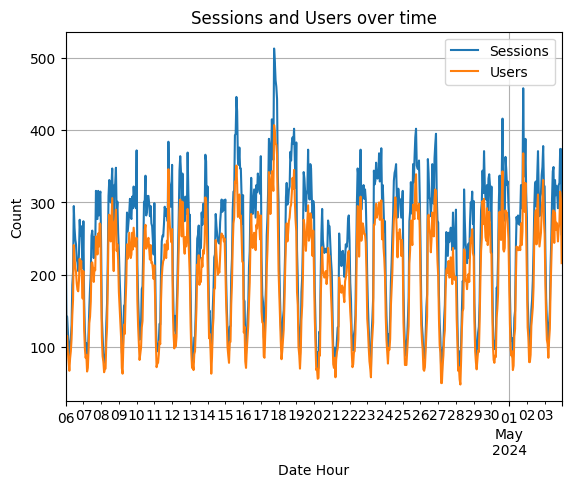

In [25]:
plt.figure(figsize=(10,5))
data.groupby("Date Hour")[["Sessions","Users"]].sum().plot()
plt.title("Sessions and Users over time")
plt.xlabel("Date Hour")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Total Users by Channel

In [26]:
data["Channel Group"].unique()

array(['Direct', 'Organic Social', 'Organic Search', 'Referral',
       'Unassigned', 'Organic Video', 'Email'], dtype=object)

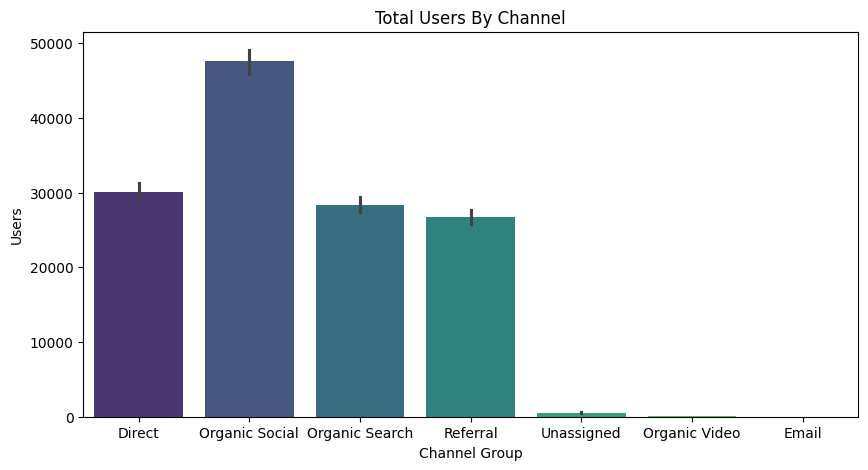

In [33]:
plt.figure(figsize=(10,5))
sns.barplot(x=data["Channel Group"],y=data["Users"],estimator=np.sum,palette="viridis")
plt.xlabel("Channel Group")
plt.ylabel("Users")
plt.title("Total Users By Channel")
plt.show()

# Average Engagement time per Session

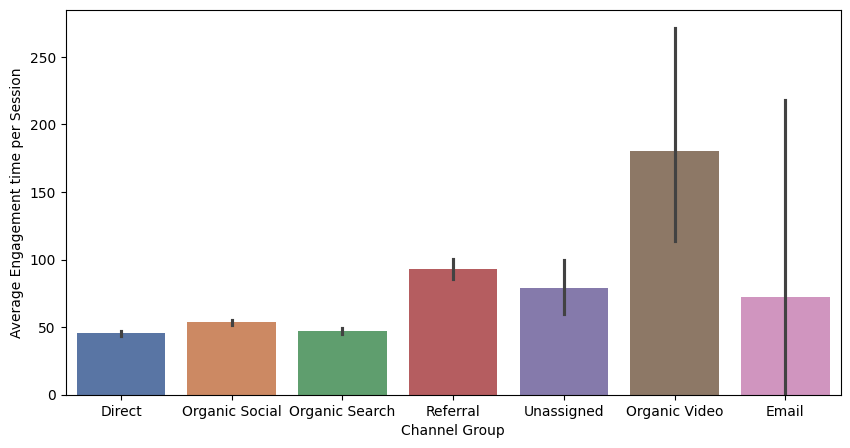

In [34]:
plt.figure(figsize=(10,5))
sns.barplot(x="Channel Group",y="Average Engagement time per Session",estimator=np.mean,data=data,palette="deep")
plt.show()

# Engagement Rate Distribution by channel

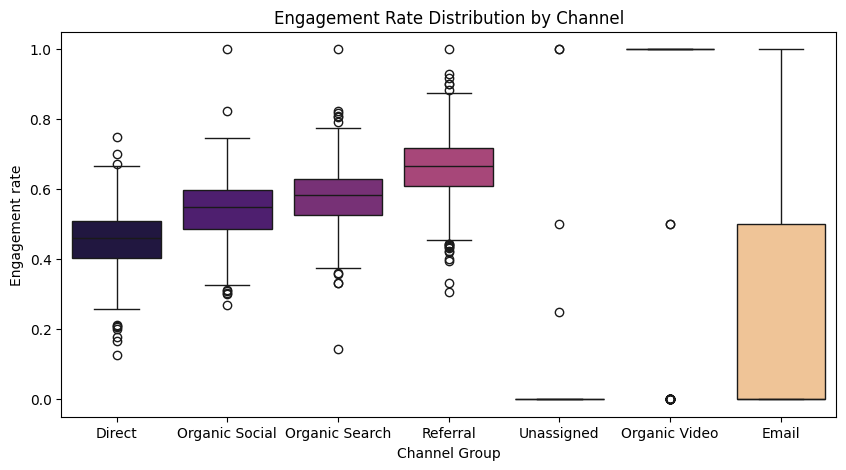

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data["Channel Group"],y=data["Engagement rate"],palette="magma")
plt.title("Engagement Rate Distribution by Channel")
plt.show()

# Engaged VS Non Engaged Sessions

In [37]:
session_data=data.groupby("Channel Group")[["Sessions","Engaged Sessions"]].sum().reset_index()
session_data["Non-Engaged"]=session_data["Sessions"]-session_data["Engaged Sessions"]
session_melted=session_data.melt(id_vars="Channel Group",value_vars=["Engaged Sessions","Non-Engaged"])

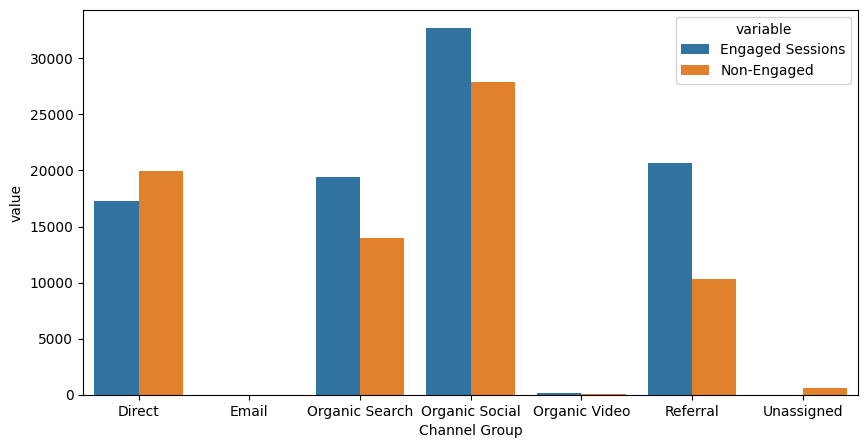

In [40]:
plt.figure(figsize=(10,5))
sns.barplot(data=session_melted,x="Channel Group",y="value",hue="variable")
plt.show()

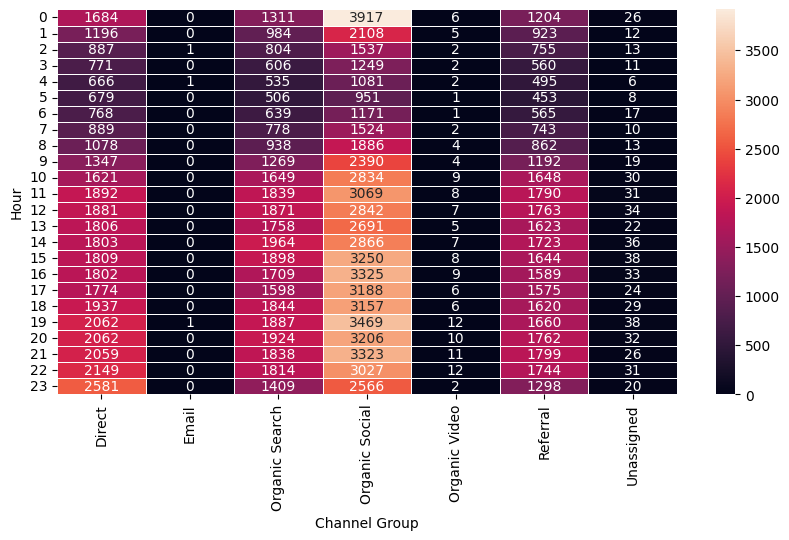

In [42]:
heatmap_data=data.groupby(["Hour","Channel Group"])["Sessions"].sum().reset_index()
heatmap_pivot = heatmap_data.pivot(index="Hour", columns="Channel Group", values="Sessions").fillna(0)

plt.figure(figsize=(10,5))
sns.heatmap(heatmap_pivot,linewidths=.5,annot=True,fmt='.0f')
plt.show()

# Engagement Rate VS Sessions Over Time

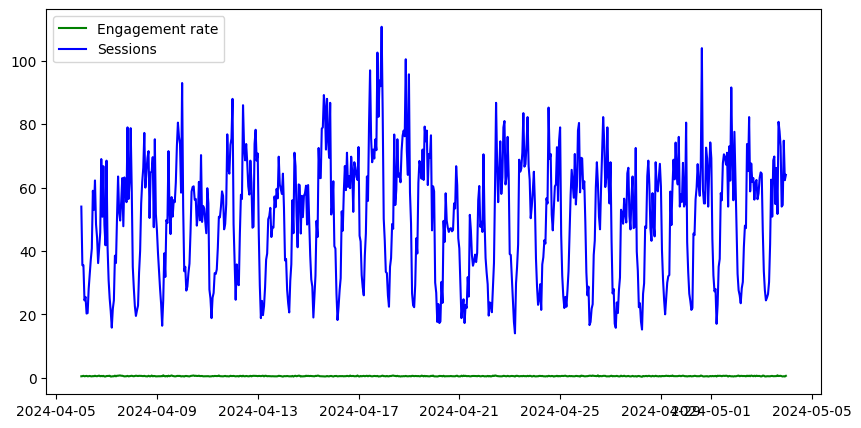

In [46]:
data_plot=data.groupby("Date Hour")[["Engagement rate","Sessions"]].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(data_plot["Date Hour"],data_plot["Engagement rate"],label="Engagement rate",color="green")
plt.plot(data_plot["Date Hour"],data_plot["Sessions"],label="Sessions",color="blue")
plt.legend()
plt.show()